# LSTM model with limited input

**Using downsampled data**

Author: Pete King

This notebook employs an LSTM with only a few hand-selected, downsampled features as input to predict historical volatility over a future outlook of 21 business days.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/downsample/W/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_base_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_base_data.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 4  # No. observation vectors in each sequence (sample)
BATCH_SIZE = 12  # For DataLoader

## I. Data Preparation

### Import and inspect financial data


In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
# Select data (X) and label (y)
data_cols = [TICKER + '_ret-h', TICKER + '_vol-h', '^VIX']
label_col = [TICKER + '_vol_target']

In [3]:
train_df[data_cols].head(SEQUENCE_LENGTH)

,SPY_ret-h,SPY_vol-h,^VIX
date,,,
2015-10-11,0.014307,0.009701,17.08
2015-10-18,0.008647,0.007959,15.05
2015-10-25,0.020153,0.009382,14.46
2015-11-01,0.004483,0.005598,15.07


In [4]:
train_df[label_col].head(SEQUENCE_LENGTH)

,SPY_vol_target
date,
2015-10-11,0.007428
2015-10-18,0.008210
2015-10-25,0.007682
2015-11-01,0.007537


### Scale data

We represent each feature in a uniform range (0, 1).

In [5]:
scaler = MinMaxScaler()
# Take care to fit scaler only to training data
X_train = scaler.fit_transform(train_df[data_cols])
y_train = train_df[label_col].values
X_val = scaler.transform(val_df[data_cols])
y_val = val_df[label_col].values

## II. PyTorch Multivariate LSTM Model


### Create Datasets and DataLoaders

For the initial investigation, we try to predict the *next period's volatility* using past observations, up to and including the current period.

In [6]:
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32),
    y_train.astype(np.float32),
    sequence_length=SEQUENCE_LENGTH,
    target=True
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32),
    y_val.astype(np.float32),
    sequence_length=SEQUENCE_LENGTH,
    target=True
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [7]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([4, 3])
Shape of first training label: torch.Size([1])


In [8]:
print(X_0)

tensor([[0.4651, 0.1162, 0.1395],
        [0.4384, 0.0928, 0.1039],
        [0.4925, 0.1119, 0.0935],
        [0.4189, 0.0610, 0.1042]])


In [9]:
print(y_0)

tensor([0.0075])


In [10]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([12, 4, 3])
Shape of first batch of labels: torch.Size([12, 1])


### Instantiate and train LSTM model


In [11]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 16  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. observations in the sequence)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [12]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [13]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(3, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


#### Loss function and Optimizer


In [14]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [15]:
# Train and evaluate model
epochs = 1000
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    if (epoch + 1) % 100 == 0:
        loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')

Training model over 1000 epochs...
Epoch 100
Training loss:   0.003014497458934784
Validation loss: 0.0011731144040822983
Epoch 200
Training loss:   0.0026302807964384556
Validation loss: 0.0005568545311689377
Epoch 300
Training loss:   0.001991867320612073
Validation loss: 0.0007061101496219635
Epoch 400
Training loss:   0.00181633944157511
Validation loss: 0.0008777203038334846
Epoch 500
Training loss:   0.0019299160921946168
Validation loss: 0.0005577905103564262
Epoch 600
Training loss:   0.0019183476688340306
Validation loss: 1.9538216292858124e-05
Epoch 700
Training loss:   0.0017294067656621337
Validation loss: 0.0001009628176689148
Epoch 800
Training loss:   0.0020256577990949154
Validation loss: 9.795930236577988e-05
Epoch 900
Training loss:   0.0016928836703300476
Validation loss: 0.00033941958099603653
Epoch 1000
Training loss:   0.0013789915246888995
Validation loss: 9.581446647644043e-06


## III. Analyze Results

### Plot of predictions vs. VIX vs. labels (final epoch)


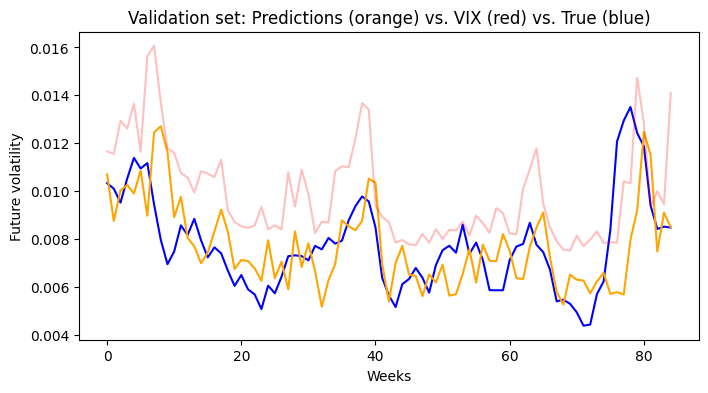

In [16]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]
# The VIX estimates annualized volatility for the next 30 days
vix = val_df['^VIX'].values[SEQUENCE_LENGTH:] / np.sqrt(252) / 100

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. VIX (red) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Weeks')
ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')
ax.plot(x, vix, color='red', alpha=0.25)

The model appears to track closely with true values, although lag is significant compared to the shorter term (5 day) forecast.  Compared to the baseline (VIX), which tends to overestimate historical volaility, our model tends to be closer to the true historical volatility value.  In fairness, I have read that the VIX has an intentional, built-in bias towards higher volatility predictions.

In [17]:
metrics = {
    'MAE': mean_absolute_error,
    'R2': r2_score,
}
# Out-of-sample R-squared compares model performance to baseline (VIX)
r2_oos = 1 - (
    mean_absolute_error(labels, preds)
    / mean_absolute_error(labels, vix)
)
# Display results
for metric, scorer in metrics.items():
    print(f'Model {metric}: {scorer(labels, preds):.5f}')
    print(f'VIX {metric}:   {scorer(labels, vix):.5f}')
    print('---')
print(f'Model R2-OOS: {r2_oos:.2f}')

Model MAE: 0.00136
VIX MAE:   0.00240
---
Model R2: 0.06180
VIX R2:   -0.96082
---
Model R2-OOS: 0.43


A positive out-of-sample R-squared indicates that our model outperforms the baseline on the validation set.